In [25]:
# Cell 1: Setup & Imports
import sys
import os
from pathlib import Path
import pandas as pd
import numpy as np

# Add project root to sys.path
project_root = str(Path().cwd().resolve())
if "notebooks" in project_root:
    project_root = str(Path().cwd().parent.resolve())
if project_root not in sys.path:
    sys.path.append(project_root)

from core.data_fetcher.aligner import CrossSectionAligner
from backtest.evaluation import FactorEvaluator
from factors.momentum.reversal import ShortTermReversal
from factors.fundamental.f_score import PiotroskiFScore

In [ ]:
# Cell 2: Load Processed Data & Mock Fundamentals
data_dict = {}
price_series_dict = {}

raw_dir = Path(project_root) / 'data' / 'processed'

print(f"Loading data from: {raw_dir}")

# Dynamically load all parquet files
for file_path in raw_dir.glob("*.parquet"):
    ticker = file_path.stem  # e.g., 'AAPL.US'
    
    try:
        df = pd.read_parquet(file_path)
        
        # Crucial Mocking Step: Add dummy fundamental columns
        # We need realistic-looking data for Piotroski F-Score to work
        n_rows = len(df)

        data_dict[ticker] = df
        
        # Extract close price for Alphalens forward return calculation
        if 'close' in df.columns:
            price_series_dict[ticker] = df['close']
            
    except Exception as e:
        print(f"Error loading {ticker}: {e}")

# Create wide DataFrame of price data (Dates x Tickers)
price_df = pd.DataFrame(price_series_dict)

print(f"Loaded {len(data_dict)} tickers into the universe.")
print(f"Price Matrix Shape: {price_df.shape}")

Loading data from: /Users/bytedance/workspace/factor_investment/data/raw
Loaded 31 tickers into the universe.
Price Matrix Shape: (4072, 31)


In [27]:
# Cell 3: Calculate Factors
reversal_factor = ShortTermReversal(lookback_period=5)
f_score_factor = PiotroskiFScore()

reversal_dict = {}
f_score_dict = {}

print("Calculating factors...")
for ticker, df in data_dict.items():
    try:
        # Calculate Reversal
        reversal_dict[ticker] = reversal_factor.compute(df)
        
        # Calculate F-Score
        f_score_dict[ticker] = f_score_factor.compute(df)
        
    except Exception as e:
        print(f"Error calculating factors for {ticker}: {e}")

print(f"Calculated Reversal for {len(reversal_dict)} tickers.")
print(f"Calculated F-Score for {len(f_score_dict)} tickers.")

Calculating factors...
Calculated Reversal for 31 tickers.
Calculated F-Score for 31 tickers.


In [28]:
# Cell 4: Cross-Sectional Alignment & Logic Filtering (The Secret Sauce)
aligner = CrossSectionAligner()

# Align both dicts into wide DataFrames
aligned_reversal = aligner.align_factors(reversal_dict)
aligned_f_score = aligner.align_factors(f_score_dict)

print(f"Aligned Reversal Shape: {aligned_reversal.shape}")
print(f"Aligned F-Score Shape: {aligned_f_score.shape}")

# The Filter Logic: Keep reversal scores ONLY IF the aligned F-Score is >= 6
# Otherwise, set the value to np.nan (effectively excluding it from the ranking)
filtered_reversal = aligned_reversal.where(aligned_f_score >= 6, np.nan)

print("Applied Quality Filter (F-Score >= 6).")

Aligned Reversal Shape: (4072, 31)
Aligned F-Score Shape: (4072, 31)
Applied Quality Filter (F-Score >= 6).


Dropped 0.3% entries from factor data: 0.3% in forward returns computation and 0.0% in binning phase (set max_loss=0 to see potentially suppressed Exceptions).
max_loss is 35.0%, not exceeded: OK!
Generating Alphalens Summary Tear Sheet...
Quantiles Statistics


,min,max,mean,std,count,count %
factor_quantile,,,,,,
1,-0.557857,0.140864,-0.037722,0.034129,16990,21.950904
2,-0.226331,0.162707,-0.013785,0.022150,14740,19.043928
3,-0.198083,0.182331,-0.002368,0.021604,14690,18.979328
4,-0.168576,0.226777,0.008978,0.022743,14739,19.042636
5,-0.121282,0.955190,0.033559,0.052055,16241,20.983204


Returns Analysis


,1D,5D,10D
Ann. alpha,0.026,0.013,0.018
beta,0.076,0.080,0.055
Mean Period Wise Return Top Quantile (bps),1.204,1.009,1.004
Mean Period Wise Return Bottom Quantile (bps),-1.409,-1.025,-0.951
Mean Period Wise Spread (bps),2.613,2.048,1.963


Information Analysis


,1D,5D,10D
IC Mean,0.012,0.015,0.017
IC Std.,0.300,0.280,0.279
Risk-Adjusted IC,0.041,0.053,0.060
t-stat(IC),2.527,3.273,3.696
p-value(IC),0.012,0.001,0.000
IC Skew,-0.006,0.051,-0.054
IC Kurtosis,-0.353,-0.234,-0.224


Turnover Analysis


,1D,5D,10D
Quantile 1 Mean Turnover,0.585,0.852,0.853
Quantile 2 Mean Turnover,0.778,0.875,0.870
Quantile 3 Mean Turnover,0.794,0.868,0.866
Quantile 4 Mean Turnover,0.770,0.872,0.872
Quantile 5 Mean Turnover,0.591,0.859,0.856


,1D,5D,10D
Mean Factor Rank Autocorrelation,0.732,-0.016,-0.013


<Figure size 640x480 with 0 Axes>

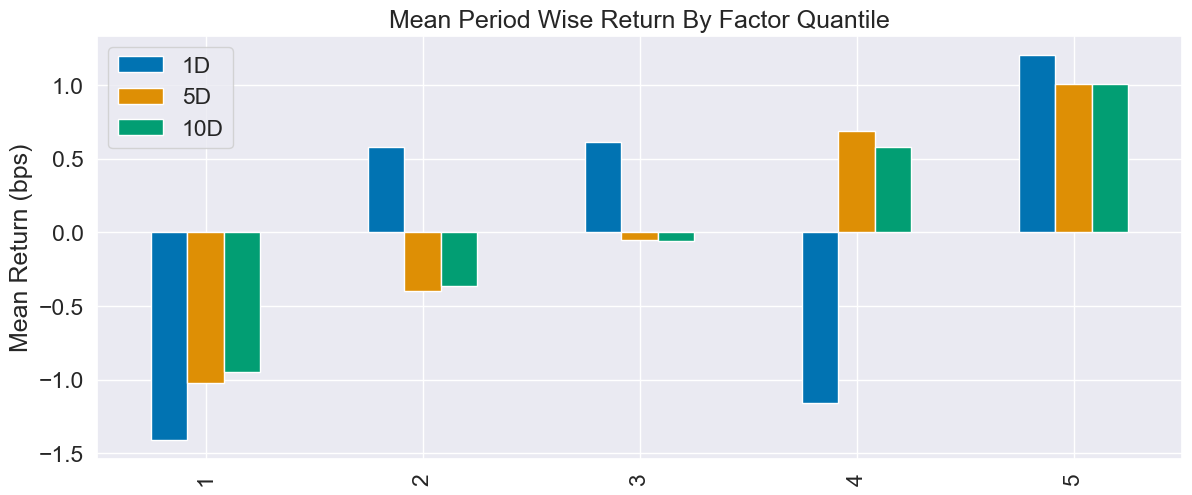

In [29]:
# Cell 5: Alphalens Evaluation
evaluator = FactorEvaluator()

try:
    # Call format_for_alphalens to get clean_factor_data
    clean_factor_data = evaluator.format_for_alphalens(filtered_reversal, price_df)
    
    # Call generate_summary_tear_sheet to display results
    print("Generating Alphalens Summary Tear Sheet...")
    evaluator.generate_summary_tear_sheet(clean_factor_data)
    
except Exception as e:
    print(f"Error during evaluation: {e}")